# Water Pipe Failure Prediction


**Authored by:**

1. **Rupanshi**
2. **Ashley Mathew**

**Duration:** 90 mins

**Level:** Intermediate

**Pre-requisite Skills:** Python, Data cleaning, Data analysis, Data visualisation, Feature Tuning, Machine Learning, XGBoost, Random Forest

### Scenario

Water pipe collapses have a substantial financial and operational impact on metropolitan utilities globally. Unexpected pipe failures can cause service disruptions, damage to roads, and costly emergency repairs. Most energy suppliers still use a reactive maintenance paradigm, responding only after a fault has occurred.

This reactive approach is costly and wasteful. Using historical data and predictive modeling is a more successful technique for predicting future pipe failures. By analyzing infrastructure attributes like pipe age, material composition, soil conditions, and long-term climatic exposure, maintenance teams may proactively check and repair high-risk pipes before they collapse.

This research applies a predictive approach to Melbourne's water delivery network, utilizing real infrastructure data from Melbourne Water Corporation.

### Introduction

This project creates a machine learning system to estimate the failure risk of water pipes in Melbourne's supply network. The analysis uses two real-world datasets accessed via public APIs:

1. **Melbourne Water Supply Main Pipelines** is a complete infrastructure dataset with 12,680 pipe records, including material type, diameter, length, soil condition, construction date, and service status.

2. **Melbourne Daily Rainfall**: 116,176 daily readings from four large harvesting storage dams (Maroondah, O'Shannassy, Thomson, and Upper Yarra) from 1927 to 2020.

The infrastructure dataset lacks an explicitly defined failure label, so a target variable is created using domain knowledge and probabilistic approaches. Failure likelihood is estimated by taking into account pipe age, material degradation risk, soil corrosivity, and cumulative climate exposure.

New features are created from raw characteristics to identify domain-specific patterns. Three ensemble models (XGBoost, Random Forest, and Gradient Boosting) are trained and compared for classifying pipes as healthy or at danger of failure.
The best-performing model assigns a risk score to each pipe, creating a prioritised maintenance shortlist to help city utilities allocate resources more efficiently.

In [ ]:
# ===== Mount Google Drive =====
from google.colab import drive
drive.mount('/content/drive')

# ===== Install required packages =====
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'imbalanced-learn', '-q'])

# ===== Import libraries =====
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, accuracy_score)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ===== Paths =====
DRIVE_PATH = '/content/drive/MyDrive/Chameleon_Project3B'
RANDOM_STATE = 42

# ===== Create folders =====
for folder in [DRIVE_PATH, f'{DRIVE_PATH}/data', f'{DRIVE_PATH}/models',
               f'{DRIVE_PATH}/outputs', f'{DRIVE_PATH}/reports']:
    os.makedirs(folder, exist_ok=True)

# ===== Chameleon Brand Palette =====
CHAM = {
    'teal':    '#0f9295',
    'blue':    '#08b3e5',
    'green':   '#2af598',
    'mint':    '#1bd7bb',
    'dark':    '#121212',
    'red':     '#e74c3c',
    'orange':  '#e67e22',
    'yellow':  '#f1c40f'
}

DUAL_COLOURS = [CHAM['green'], CHAM['red']]
TRI_COLOURS = [CHAM['teal'], CHAM['orange'], CHAM['green']]
GRADIENT_5 = [CHAM['green'], CHAM['mint'], CHAM['yellow'], CHAM['orange'], CHAM['red']]

# ===== Chart Style =====
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# ===== Melbourne Water Reference Dictionaries =====
MATERIAL_LIFESPAN = {
    'MS': 70, 'MSCL': 80, 'MSEL': 75, 'MSLB': 75,
    'CI': 100, 'CICL': 110, 'DICL': 100,
    'RC': 75, 'CONC': 75, 'OTHER': 75, 'UNKNOWN': 75
}

SOIL_CORROSIVITY_MAP = {
    'CLAY': 4, 'MS': 4, 'CRK': 3, 'SNC': 3, 'S&C': 3,
    'SS&C': 3, 'SAND': 2, 'TOPS': 2, 'UNKNOWN': 3, 'OTHER': 3
}

MATERIAL_RISK = {
    'CI': 0.8, 'CICL': 0.7, 'MS': 0.6, 'MSCL': 0.5,
    'MSEL': 0.4, 'MSLB': 0.4, 'RC': 0.3, 'DICL': 0.2,
    'CONC': 0.3, 'OTHER': 0.4, 'UNKNOWN': 0.4
}

SOIL_RISK = {
    'CLAY': 0.7, 'MS': 0.6, 'CRK': 0.5, 'SNC': 0.5,
    'S&C': 0.5, 'SS&C': 0.4, 'SAND': 0.3, 'TOPS': 0.3,
    'UNKNOWN': 0.4, 'OTHER': 0.4
}

print("Setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete!


## Data Processing
The Melbourne Water pipeline dataset is accessible through the ArcGIS REST API. Data is downloaded in batches of 2,000 records to manage the entire dataset of about 12,680 pipes.

In [ ]:
print("Downloading Melbourne Water Supply Pipeline dataset...\n")

url = ("https://services5.arcgis.com/ZSYwjtv8RKVhkXIL/arcgis/rest/services/"
       "Water_Supply_Main_Pipelines/FeatureServer/0/query")

all_records = []
offset = 0
batch_size = 2000

while True:
    params = {
        'where': '1=1', 'outFields': '*', 'f': 'json',
        'resultRecordCount': batch_size, 'resultOffset': offset
    }
    response = requests.get(url, params=params, timeout=60)
    data = response.json()

    if 'features' not in data or len(data['features']) == 0:
        break

    records = [f['attributes'] for f in data['features']]
    all_records.extend(records)
    print(f"  Batch: {len(records)} records (total: {len(all_records)})")

    if len(records) < batch_size:
        break
    offset += batch_size

melbourne_raw = pd.DataFrame(all_records)
melbourne_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_pipes.csv', index=False)

print(f"\nTotal: {len(melbourne_raw)} records, {len(melbourne_raw.columns)} columns")


  Batch: 2000 records (total: 2000)
  Batch: 2000 records (total: 4000)
  Batch: 2000 records (total: 6000)
  Batch: 2000 records (total: 8000)
  Batch: 2000 records (total: 10000)
  Batch: 2000 records (total: 12000)
  Batch: 680 records (total: 12680)

Total: 12680 records, 37 columns


##Dataset Construction
### Melbourne Water Supply Main Pipelines

This dataset is obtained directly from the Melbourne Water Corporation via the Victorian Government's open data portal (data.vic.gov.au). It may be accessible using the ArcGIS REST API and contains genuine infrastructure data managed by the utility in charge of Melbourne's water delivery network.

The raw dataset consists of **12,680 pipe records** across **37 columns**. Each row indicates one water main pipeline segment. Key characteristics include:

- **Pipe identity:** OBJECTID, ASSET_ID, and UNITID
- **Infrastructure attributes:** Material, Pipe Width, Pipe Length, Date of Construction
- **Ecological context:** SOIL_TYPE, SUBAREA
- **Operational history:** DATE_RELINED; SERVICE_STATUS

### Target Variable Construction

Because the dataset lacks an explicit failure label, a **probabilistic target variable** is created using domain-specific characteristics. A pipe is considered **at risk** if the predicted failure probability exceeds the 65th percentile.

In [ ]:
print("Constructing Melbourne water pipe dataset...\n")

np.random.seed(RANDOM_STATE)

df = melbourne_raw.copy()

# 1. Convert timestamps to years
df['installation_year'] = pd.to_datetime(
    df['DATE_OF_CONSTRUCTION'], unit='ms', errors='coerce'
).dt.year
df = df.dropna(subset=['installation_year'])
df['installation_year'] = df['installation_year'].astype(int)
df = df[(df['installation_year'] >= 1900) & (df['installation_year'] <= 2024)]

# 2. Pipe age
df['pipe_age'] = 2024 - df['installation_year']

# 3. Material
df['material'] = df['MATERIAL'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
common_materials = df['material'].value_counts().head(10).index.tolist()
df['material'] = df['material'].apply(lambda x: x if x in common_materials else 'OTHER')

# 4. Soil
df['soil_type'] = df['SOIL_TYPE'].fillna('UNKNOWN').astype(str).str.upper().str.strip()
df['soil_type'] = df['soil_type'].replace({'UNKN': 'UNKNOWN'})
common_soils = df['soil_type'].value_counts().head(8).index.tolist()
df['soil_type'] = df['soil_type'].apply(lambda x: x if x in common_soils else 'OTHER')

# 5. Dimensions
df['diameter_mm'] = pd.to_numeric(df['PIPE_WIDTH'], errors='coerce')
df['length_m'] = pd.to_numeric(df['PIPE_LENGTH'], errors='coerce')
df = df.dropna(subset=['diameter_mm', 'length_m'])
df = df[(df['diameter_mm'] > 0) & (df['diameter_mm'] < 5000)]
df = df[(df['length_m'] > 0) & (df['length_m'] < 50000)]

# 6. Operational flags
df['has_been_relined'] = df['DATE_RELINED'].notna().astype(int)
df['is_in_service'] = (df['SERVICE_STATUS'] == 'IN').astype(int)

# 7. Probabilistic target (with noise for realism)
failure_prob = (
    (df['pipe_age'] / 120) * 0.20 +
    df['material'].map(MATERIAL_RISK).fillna(0.4) * 0.15 +
    df['soil_type'].map(SOIL_RISK).fillna(0.4) * 0.10 +
    (df['has_been_relined'] * 0.15) +
    (df['diameter_mm'] < 200).astype(float) * 0.05 +
    (df['length_m'] > 50).astype(float) * 0.05 +
    np.random.uniform(0, 0.30, len(df))
)

threshold_target = np.percentile(failure_prob, 65)
df['failed'] = (failure_prob > threshold_target).astype(int)

# 8. Final columns
df_clean = df[[
    'OBJECTID', 'installation_year', 'pipe_age', 'material',
    'diameter_mm', 'length_m', 'soil_type',
    'has_been_relined', 'is_in_service', 'failed'
]].rename(columns={'OBJECTID': 'pipe_id'}).reset_index(drop=True)

df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_clean.csv', index=False)

print(f"Dataset: {len(df_clean):,} pipes")
print(f"  Failed: {df_clean['failed'].sum():,} ({df_clean['failed'].mean()*100:.1f}%)")
print(f"  Healthy: {(df_clean['failed']==0).sum():,} ({(1-df_clean['failed'].mean())*100:.1f}%)")
print(f"\nMaterials:\n{df_clean['material'].value_counts().head(10)}")
print(f"\nSoil Types:\n{df_clean['soil_type'].value_counts().head(10)}")

Constructing Melbourne water pipe dataset...

Dataset: 11,541 pipes
  Failed: 4,039 (35.0%)
  Healthy: 7,502 (65.0%)

Materials:
material
MS         6468
MSCL       3216
OTHER       486
RC          298
MSEL        271
CI          182
CICL        164
MSLB        162
UNKNOWN     150
DICL         87
Name: count, dtype: int64

Soil Types:
soil_type
UNKNOWN    5588
CLAY       3013
CRK        1224
SAND       1161
SNC         188
OTHER       156
S&C          90
TOPS         80
SS&C         41
Name: count, dtype: int64


### Melbourne Daily Rainfall Data

The second dataset contains daily rainfall readings collected from Melbourne Water's four primary harvesting storage dams. This data is accessible via the CKAN Datastore API on data.vic.gov.au and spans the years 1927 to 2020.

Rainfall data is incorporated into the pipe dataset to account for **long-term climatic exposure**, a recognised contributor to ground movement and pipe stress.

In [ ]:
print("Downloading Melbourne Daily Rainfall...\n")

url_rain = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

all_rainfall = []
offset = 0
batch_size = 10000

while True:
    params = {
        'resource_id': '513228d8-401e-41df-956c-df52c814ecba',
        'limit': batch_size, 'offset': offset
    }
    response = requests.get(url_rain, params=params, timeout=120)
    data = response.json()

    if not data['success'] or len(data['result']['records']) == 0:
        break

    records = data['result']['records']
    all_rainfall.extend(records)
    print(f"  Batch: {len(records)} (total: {len(all_rainfall)})")

    if len(records) < batch_size:
        break
    offset += batch_size

rainfall_raw = pd.DataFrame(all_rainfall)
rainfall_raw.to_csv(f'{DRIVE_PATH}/data/raw_melbourne_rainfall.csv', index=False)

print(f"\nTotal: {len(rainfall_raw):,} records")


  Batch: 10000 (total: 10000)
  Batch: 10000 (total: 20000)
  Batch: 10000 (total: 30000)
  Batch: 10000 (total: 40000)
  Batch: 10000 (total: 50000)
  Batch: 10000 (total: 60000)
  Batch: 10000 (total: 70000)
  Batch: 10000 (total: 80000)
  Batch: 10000 (total: 90000)
  Batch: 10000 (total: 100000)
  Batch: 10000 (total: 110000)
  Batch: 6176 (total: 116176)

Total: 116,176 records


In [ ]:
print("Processing rainfall data...\n")

rf = rainfall_raw.copy()
rf['rainfall_mm'] = pd.to_numeric(rf['rainfall_mm'], errors='coerce')
rf = rf.dropna(subset=['rainfall_mm'])
rf['date'] = pd.to_datetime(rf['recorddate'], errors='coerce')
rf = rf.dropna(subset=['date'])
rf['year'] = rf['date'].dt.year

dam_annual = rf.groupby(['year', 'dam'])['rainfall_mm'].sum().unstack(fill_value=0)
avg_annual_rainfall = dam_annual.mean(axis=1)
threshold_rf = avg_annual_rainfall.quantile(0.80)
extreme_years = avg_annual_rainfall[avg_annual_rainfall > threshold_rf].index.tolist()

print(f"Rainfall range: {rf['year'].min()}-{rf['year'].max()}")
print(f"Average annual: {avg_annual_rainfall.mean():.1f} mm")
print(f"Wettest year: {avg_annual_rainfall.idxmax()} ({avg_annual_rainfall.max():.1f} mm)")
print(f"Driest year: {avg_annual_rainfall.idxmin()} ({avg_annual_rainfall.min():.1f} mm)")
print(f"Extreme years: {len(extreme_years)}")

Processing rainfall data...

Rainfall range: 1892-2020
Average annual: 729.4 mm
Wettest year: 2011 (1410.0 mm)
Driest year: 1927 (212.5 mm)
Extreme years: 26


In [ ]:
print("Adding rainfall features to pipe data...\n")

rainfall_lookup = avg_annual_rainfall.to_dict()

df_clean['rainfall_install_year'] = df_clean['installation_year'].map(rainfall_lookup)
df_clean['rainfall_install_year'] = df_clean['rainfall_install_year'].fillna(avg_annual_rainfall.mean())

def calc_lifetime_rainfall(iy):
    return np.mean([rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(iy, 2025)])

df_clean['avg_lifetime_rainfall'] = df_clean['installation_year'].apply(calc_lifetime_rainfall)
df_clean['extreme_rain_years'] = df_clean['installation_year'].apply(
    lambda x: sum(1 for y in range(x, 2025) if y in extreme_years))
df_clean['cumulative_rainfall'] = df_clean['installation_year'].apply(
    lambda x: sum(rainfall_lookup.get(y, avg_annual_rainfall.mean()) for y in range(x, 2025)))

max_rain = avg_annual_rainfall.max()
df_clean['climate_stress'] = (
    (df_clean['avg_lifetime_rainfall'] / max_rain) * 0.4 +
    (df_clean['extreme_rain_years'] / max(df_clean['extreme_rain_years'].max(), 1)) * 0.3 +
    (df_clean['cumulative_rainfall'] / max(df_clean['cumulative_rainfall'].max(), 1)) * 0.3
)

df_clean.to_csv(f'{DRIVE_PATH}/data/melbourne_pipes_enriched.csv', index=False)

print(f"Enriched: {len(df_clean):,} pipes with rainfall features")
print(df_clean[['pipe_id', 'pipe_age', 'material', 'rainfall_install_year',
                'climate_stress', 'failed']].head(10))

Adding rainfall features to pipe data...

Enriched: 11,541 pipes with rainfall features
   pipe_id  pipe_age material  rainfall_install_year  climate_stress  failed
0        1         7     MSCL                 1105.5        0.267338       0
1        2         7     MSCL                 1105.5        0.267338       0
2        3        13     MSCL                 1410.0        0.375594       0
3        4         7       MS                 1105.5        0.267338       0
4        5        13     MSCL                 1410.0        0.375594       0
5        6         7     MSCL                 1105.5        0.267338       0
6        7         7     MSCL                 1105.5        0.267338       0
7        8         7     MSCL                 1105.5        0.267338       0
8        9         7     MSCL                 1105.5        0.267338       0
9       10         7     MSCL                 1105.5        0.267338       0


---

## Exploratory Data Analysis

The following visualizations look at failure patterns across pipe age, material type, soil conditions, and climate exposure. These analyses assist in determining which infrastructural and environmental elements are most strongly connected with pipe failure risk.

**Pipe Failure Distribution**

This graph depicts the overall breakdown of healthy pipes and pipes identified as at risk of failure in the dataset. Understanding the class balance is critical before modeling since a significantly imbalanced dataset may cause the model to favor predicting the majority class. Approximately 65% of the pipes are healthy, while 35% are at danger, indicating a modest imbalance that will be rectified with SMOTE during model training.


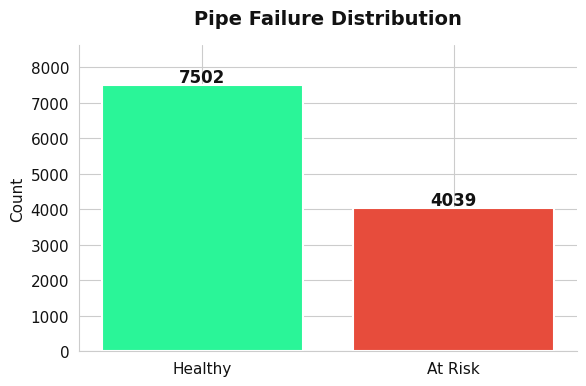

In [ ]:
sns.set_style("whitegrid")

# Chart 1: Failure Distribution
fig, ax = plt.subplots(figsize=(6, 4))

counts = df_clean['failed'].value_counts()
bars = ax.bar(['Healthy', 'At Risk'], counts.values,
              colour=DUAL_COLOURS, edgecolour='white', linewidth=1.5)

for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., v + 80, str(v),
            ha='center', fontsize=12, fontweight='bold', colour=CHAM['dark'])

ax.set_title("Pipe Failure Distribution", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_ylabel("Count", fontsize=11, colour=CHAM['dark'])
ax.set_ylim(0, max(counts.values) * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Failure Rate by Pipe Material**

This graphic examines failure rates for various pipe materials used in Melbourne's water network. The material composition of pipes is an important factor in determining their lifespan. Legacy ferrous materials, such as Cast Iron (CI) and Mild Steel (MS), have been shown to be more prone to corrosion and structural degradation with time, whereas newer materials, such as Ductile Iron Cement-Lined (DICL), are designed for higher longevity. Identifying which materials pose the greatest failure risk aids in the prioritization of inspection and replacement programs.


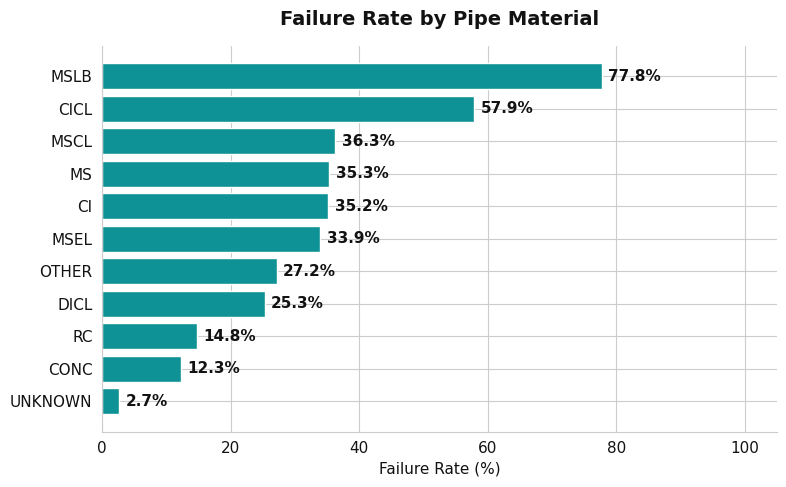

In [ ]:
# Chart 2: Failure Rate by Material
fig, ax = plt.subplots(figsize=(8, 5))

mat_fail = df_clean.groupby('material')['failed'].mean().sort_values() * 100
bars = ax.barh(mat_fail.index, mat_fail.values, colour=CHAM['teal'],
               edgecolour='white', linewidth=1)

for bar, v in zip(bars, mat_fail.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=11, fontweight='bold', colour=CHAM['dark'])

ax.set_title("Failure Rate by Pipe Material", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_xlabel("Failure Rate (%)", fontsize=11, colour=CHAM['dark'])
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Pipe Age Distribution by Failure Status**

This graph examines the age distribution of healthy and at-risk pipes using kernel density estimation. Older pipes are more likely to fail owing to material fatigue, corrosion, and degradation after their projected service life. A clear separation between the two distributions would demonstrate that pipe age is a useful predictor of failure probability, justifying the inclusion of age-based characteristics like age_ratio and remaining_life in the model.


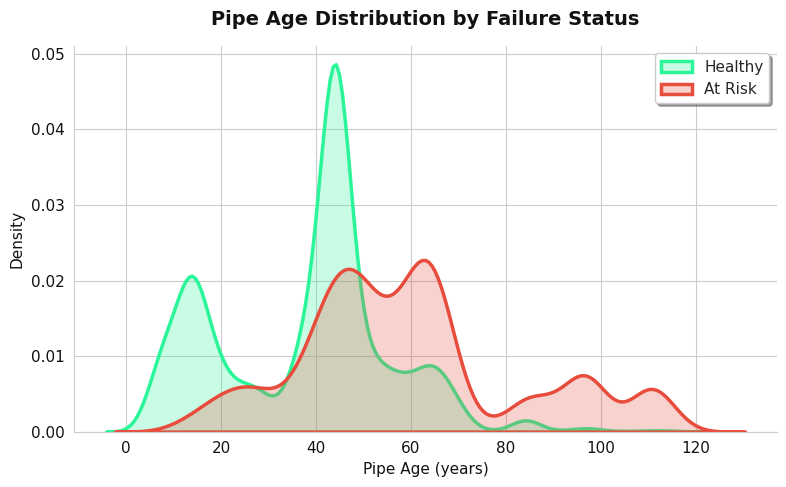

In [ ]:
# Chart 3: Age Distribution
fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(df_clean[df_clean['failed'] == 0]['pipe_age'],
            fill=True, label='Healthy', colour=CHAM['green'], linewidth=2.5, ax=ax)
sns.kdeplot(df_clean[df_clean['failed'] == 1]['pipe_age'],
            fill=True, label='At Risk', colour=CHAM['red'], linewidth=2.5, ax=ax)

ax.set_title("Pipe Age Distribution by Failure Status", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_xlabel("Pipe Age (years)", fontsize=11, colour=CHAM['dark'])
ax.set_ylabel("Density", fontsize=11, colour=CHAM['dark'])
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Failure Rate by Soil Type**

This figure looks at how varying soil conditions around Melbourne's pipe network affect failure risk. Soil type influences the rate of external corrosion on metallic pipes. Clay soils absorb moisture and provide electrochemical conditions that promote corrosion, whereas sandy soils are less corrosive. Understanding soil-related risk explains why two pipes of the same age and composition can fail at very different rates depending on where they are installed.


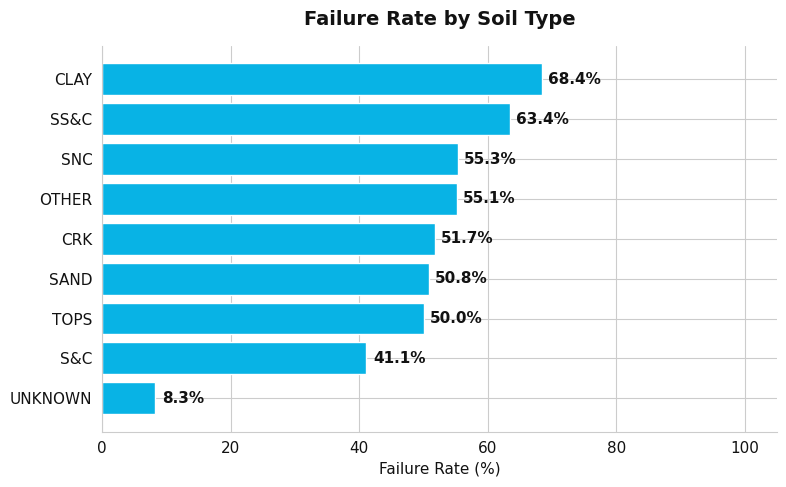

In [ ]:
# Chart 4: Failure by Soil Type
fig, ax = plt.subplots(figsize=(8, 5))

soil_fail = df_clean.groupby('soil_type')['failed'].mean().sort_values() * 100
bars = ax.barh(soil_fail.index, soil_fail.values, colour=CHAM['blue'],
               edgecolour='white', linewidth=1)

for bar, v in zip(bars, soil_fail.values):
    ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=11, fontweight='bold', colour=CHAM['dark'])

ax.set_title("Failure Rate by Soil Type", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_xlabel("Failure Rate (%)", fontsize=11, colour=CHAM['dark'])
ax.set_xlim(0, 105)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Melbourne Annual Rainfall (1892-2020)**

This graph depicts annual rainfall totals for Melbourne Water's four primary dam catchments from 1892 to 2020. Years that exceeded the 80th percentile mark, denoted by red bars, were classed as exceptional rainfall years. Prolonged or intense rainfall causes ground movement and hydraulic stress, which can speed up pipe joint failure and exterior corrosion. A climate-based risk component can be added to the predictive model by measuring how many years of extreme rainfall a pipe has seen over its lifetime.


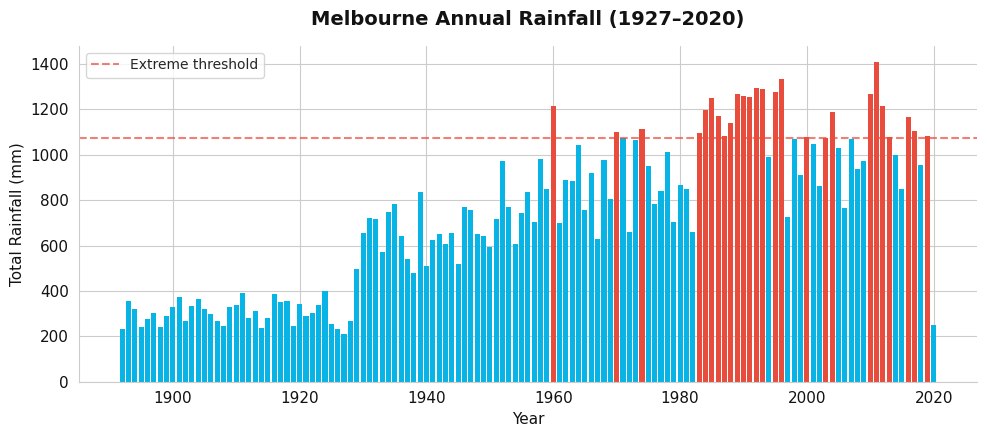

In [ ]:
# Chart 5: Rainfall Over Time
fig, ax = plt.subplots(figsize=(10, 4.5))

COLOURS = [CHAM['red'] if y in extreme_years else CHAM['blue']
          for y in avg_annual_rainfall.index]

ax.bar(avg_annual_rainfall.index, avg_annual_rainfall.values, colour=COLOURS, edgecolour='none')
ax.axhline(y=threshold_rf, colour=CHAM['red'], linestyle='--', linewidth=1.5,
           alpha=0.7, label='Extreme threshold')

ax.set_title("Melbourne Annual Rainfall (1927–2020)", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_xlabel("Year", fontsize=11, colour=CHAM['dark'])
ax.set_ylabel("Total Rainfall (mm)", fontsize=11, colour=CHAM['dark'])
ax.legend(fontsize=10, frameon=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Failure Rate by Climate Stress Level**

This graph separates pipes into five equal groups (quintiles) based on their total climate stress score and compares failure rates within each category. The climatic stress score is a composite statistic that takes into consideration average lifetime rainfall, the number of years with exceptional rainfall, and the total cumulative rainfall since installation. A clear increased trend in failure rates from the lowest to highest climate stress quintiles would confirm that long-term climate exposure is a significant factor to pipe failure risk in Melbourne's network.


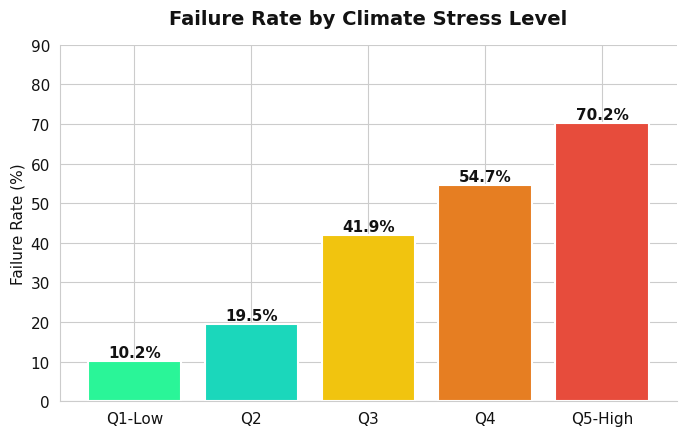

In [ ]:
# Chart 6: Climate Stress vs Failure
if 'climate_quintile' not in df_clean.columns:
    df_clean['climate_quintile'] = pd.qcut(df_clean['climate_stress'], q=5,
                                            labels=['Q1-Low', 'Q2', 'Q3', 'Q4', 'Q5-High'])

climate_fail = df_clean.groupby('climate_quintile')['failed'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(climate_fail.index.astype(str), climate_fail.values,
              colour=GRADIENT_5, edgecolour='white', linewidth=1.5)

for bar, v in zip(bars, climate_fail.values):
    ax.text(bar.get_x() + bar.get_width()/2., v + 1, f'{v:.1f}%',
            ha='center', fontsize=11, fontweight='bold', colour=CHAM['dark'])

ax.set_title("Failure Rate by Climate Stress Level", fontsize=14, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.set_ylabel("Failure Rate (%)", fontsize=11, colour=CHAM['dark'])
ax.set_ylim(0, 90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Feature Correlation Matrix**

This heatmap depicts the pairwise associations between major numerical features and failure labels. Positive numbers suggest that as one variable increases, the other follows suit. Negative values represent an inverse relationship. Examining correlations prior to modeling aids in determining which raw features are more strongly linked with failure, as well as any multicollinearity between features that may need to be addressed during feature engineering.


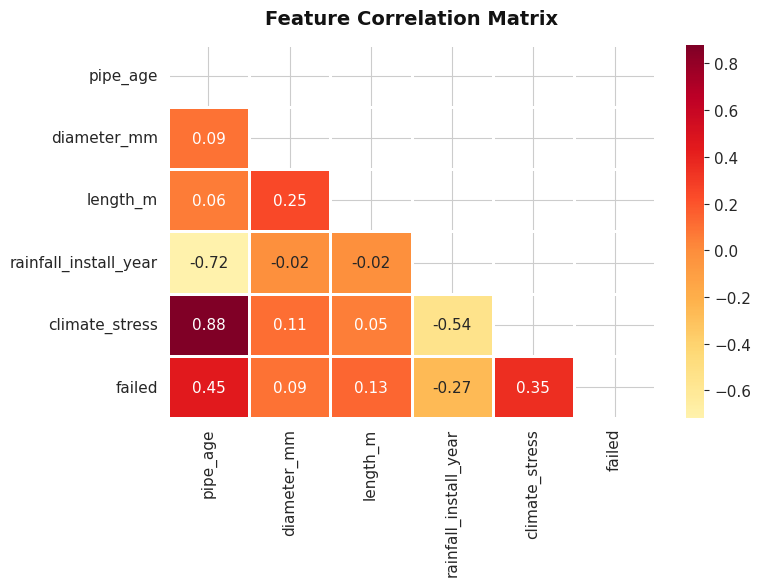

In [ ]:
# Chart 7: Correlation Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

num_cols = ['pipe_age', 'diameter_mm', 'length_m', 'rainfall_install_year',
            'climate_stress', 'failed']
mask = np.triu(np.ones_like(df_clean[num_cols].corr(), dtype=bool))

sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='YlOrRd',
            center=0, fmt='.2f', linewidths=1, linecolour='white',
            mask=mask, annot_kws={'fontsize': 11}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight='bold',
             colour=CHAM['dark'], pad=15)
plt.tight_layout()
plt.show()

---

## Feature Engineering

Several domain-specific features are derived from the raw pipe and rainfall data to improve model performance.

| Feature | Description |
|---|---|
| age_ratio | Pipe age divided by material lifespan |
| remaining_life | Normalised estimate of useful life remaining |
| soil_corrosivity_score | Numeric score based on soil type |
| high_risk_material | Binary flag for legacy materials (CI, MS) |
| high_risk_soil | Binary flag for corrosive soils (CLAY) |
| climate_stress | Composite score from rainfall exposure |
| cumulative_rainfall | Total rainfall during pipe's lifetime |
| extreme_rain_years | Count of above-average rainfall years |
| combined_risk | Weighted aggregate of all risk factors |

---

## Model Evaluation

Three ensemble models are trained and compared:

1. **XGBoost** — Gradient boosting with regularisation
2. **Random Forest** — Bagging ensemble with feature randomisation
3. **Gradient Boosting** — Sequential error correction

SMOTE is applied to handle class imbalance. Standard scaling is applied to all numeric features.

In [ ]:
print("Feature engineering and model training...\n")

def engineer_features(data):
    d = data.copy()
    d['material_lifespan'] = d['material'].map(MATERIAL_LIFESPAN).fillna(75)
    d['age_ratio'] = d['pipe_age'] / d['material_lifespan']
    d['remaining_life'] = np.clip(1 - d['age_ratio'], 0, 1)
    d['is_old'] = (d['pipe_age'] > 50).astype(int)
    d['diameter_log'] = np.log1p(d['diameter_mm'])
    d['length_log'] = np.log1p(d['length_m'])
    d['is_large_pipe'] = (d['diameter_mm'] > 300).astype(int)
    d['soil_corrosivity_score'] = d['soil_type'].map(SOIL_CORROSIVITY_MAP).fillna(3)
    d['high_risk_material'] = d['material'].isin(['CI', 'CICL', 'MS', 'MSCL']).astype(int)
    d['high_risk_soil'] = d['soil_type'].isin(['CLAY', 'MS']).astype(int)
    d['combined_risk'] = (
        d['age_ratio'] * 0.30 +
        (d['soil_corrosivity_score'] / 5) * 0.15 +
        d['high_risk_material'] * 0.15 +
        d['high_risk_soil'] * 0.10 +
        d['climate_stress'] * 0.20 +
        d['extreme_rain_years'] / max(d['extreme_rain_years'].max(), 1) * 0.10
    )
    return d

df_features = engineer_features(df_clean)

# Encode categoricals
for col in ['material', 'soil_type']:
    le = LabelEncoder()
    df_features[col + '_enc'] = le.fit_transform(df_features[col])

# Prepare model data
drop_cols = ['pipe_id', 'installation_year', 'material', 'soil_type',
             'has_been_relined', 'is_in_service', 'climate_quintile']
df_model = df_features.drop([c for c in drop_cols if c in df_features.columns], axis=1)
df_model = df_model.drop(df_model.select_dtypes(include=['object']).columns, axis=1)

y = df_model['failed']
X = df_model.drop('failed', axis=1)
feature_names = X.columns.tolist()

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Scale
scaler = StandardScaler()
X_train_bal = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=feature_names)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names)

# Train models
models = {
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, eval_metric='logloss'),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=15,
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1,
                                                     random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"{name}: Acc={results[name]['accuracy']:.4f} | F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f}")

best_name = max(results, key=lambda k: results[k]['auc'])
print(f"\nBest: {best_name} (AUC={results[best_name]['auc']:.4f})")
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['No Failure', 'Failure']))

Feature engineering and model training...

XGBoost: Acc=0.7951 | F1=0.7255 | AUC=0.8773
Random Forest: Acc=0.7943 | F1=0.7293 | AUC=0.8741
Gradient Boosting: Acc=0.8038 | F1=0.7413 | AUC=0.8816

Best: Gradient Boosting (AUC=0.8816)
              precision    recall  f1-score   support

  No Failure       0.88      0.80      0.84      1501
     Failure       0.69      0.80      0.74       808

    accuracy                           0.80      2309
   macro avg       0.79      0.80      0.79      2309
weighted avg       0.82      0.80      0.81      2309



**Model Performance Comparison**

This chart compares all three models based on three evaluation metrics: accuracy, F1 Score, and AUC-ROC. Accuracy indicates overall correctness, however it can be misleading when dealing with imbalanced data. F1 Score strikes a compromise between precision and recall, which is critical when both false positives (unnecessary inspections) and false negatives (missed failures) incur substantial operational costs. The major ranking indicator is AUC-ROC, which assesses the model's ability to distinguish at-risk pipes from healthy ones across all decision thresholds, regardless of class imbalance.


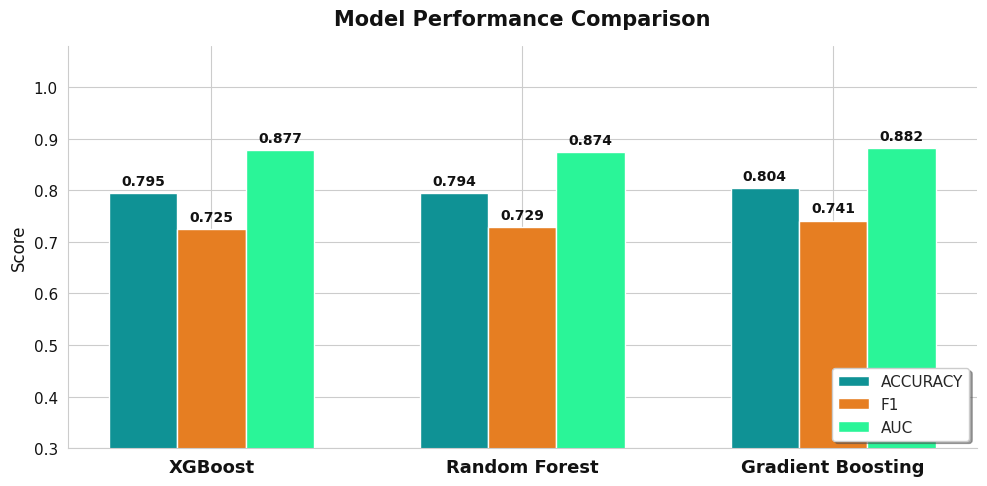

In [ ]:
# Chart 8: Model Comparison
fig, ax = plt.subplots(figsize=(10, 5))

names = list(results.keys())
x = np.arange(len(names))
bar_width = 0.22
metrics = ['accuracy', 'f1', 'auc']

for i, (metric, colour) in enumerate(zip(metrics, TRI_COLOURS)):
    bars = ax.bar(x + i * bar_width, [results[n][metric] for n in names],
                  bar_width, label=metric.upper(), colour=colour,
                  edgecolour='white', linewidth=1)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold', colour=CHAM['dark'])

ax.set_xticks(x + bar_width)
ax.set_xticklabels(names, fontsize=13, fontweight='bold', colour=CHAM['dark'])
ax.set_ylim(0.3, 1.08)
ax.set_ylabel('Score', fontsize=12, colour=CHAM['dark'])
ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**ROC Curves**

The Receiver Operating Characteristic (ROC) curve compares the True Positive Rate (properly identified failures) against the False Positive Rate (healthy pipes wrongly flagged) at each classification level. A model that performs no better than random guessing yields a diagonal line with an AUC of 0.5. The model's ability to distinguish between at-risk and healthy pipes improves as the curve moves toward the top-left corner. Comparing the curves of all three models allows us to objectively identify the best-performing model.

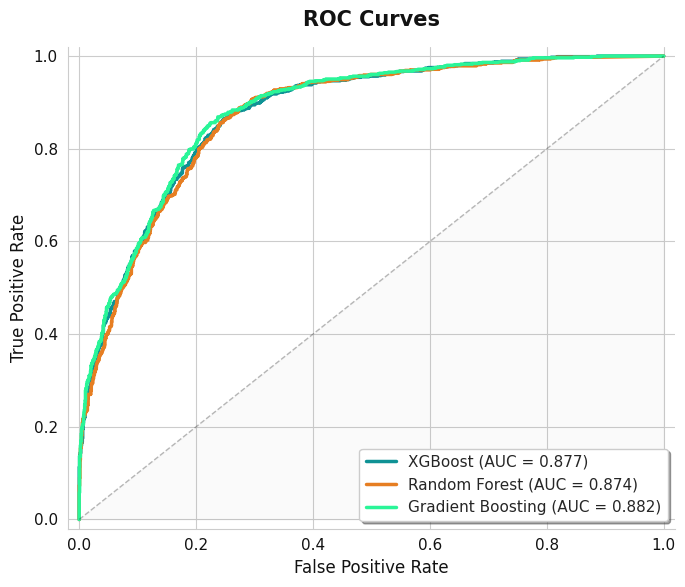

In [ ]:
# Chart 9: ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))

for (name, r), colour in zip(results.items(), TRI_COLOURS):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, colour=colour, linewidth=2.5,
            label=f"{name} (AUC = {r['auc']:.3f})")

ax.plot([0, 1], [0, 1], colour=CHAM['dark'], linestyle='--', alpha=0.3, linewidth=1)
ax.fill_between([0, 1], [0, 1], alpha=0.02, colour=CHAM['dark'])
ax.set_xlabel('False Positive Rate', fontsize=12, colour=CHAM['dark'])
ax.set_ylabel('True Positive Rate', fontsize=12, colour=CHAM['dark'])
ax.set_title('ROC Curves', fontsize=15, fontweight='bold', colour=CHAM['dark'], pad=15)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Confusion Matrix**

The confusion matrix depicts the breakdown of correct and wrong predictions for the best-performing model on the test dataset. It shows four values: true positives (at-risk pipes accurately detected), true negatives (healthy pipes correctly recognized), false positives (healthy pipes wrongly classified as at-risk), and false negatives (at-risk pipes overlooked by the model). False negatives are especially costly in pipe failure prediction because they reflect pipes that are actually at danger but are not reported for inspection.




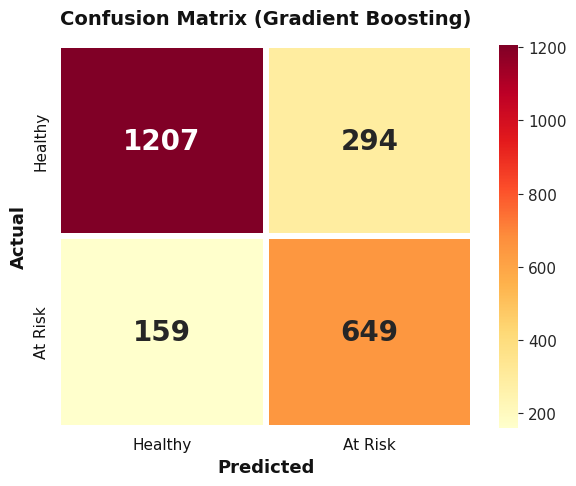

In [ ]:
# Chart 10: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Healthy', 'At Risk'], yticklabels=['Healthy', 'At Risk'],
            linewidths=3, linecolour='white',
            annot_kws={'size': 20, 'fontweight': 'bold'}, ax=ax)
ax.set_ylabel('Actual', fontsize=13, fontweight='bold', colour=CHAM['dark'])
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold', colour=CHAM['dark'])
ax.set_title(f'Confusion Matrix ({best_name})', fontsize=14, fontweight='bold',
             colour=CHAM['dark'], pad=15)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Feature Importance**

This graph depicts which features had the biggest impact on the best-performing model's predictions. The feature significance values show how much each input variable helped to reduce prediction error across all decision trees in the ensemble. Higher significance indicates that the model relied more on that feature while identifying pipes. This research verifies previous feature engineering decisions and assists in determining which infrastructure and environmental factors are the most significant drivers of pipe failure risk in Melbourne's network.



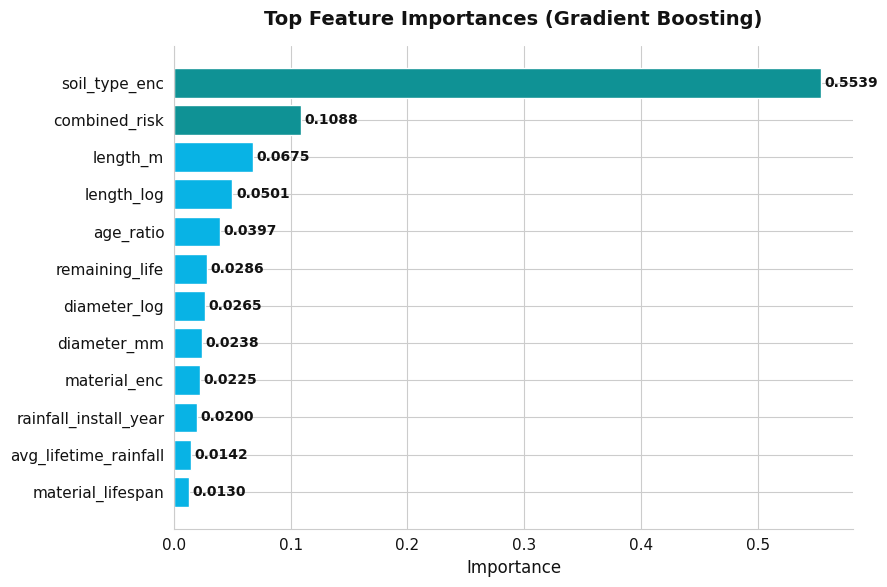

In [ ]:
# Chart 11: Feature Importance
fig, ax = plt.subplots(figsize=(9, 6))

best_model = results[best_name]['model']
imp = best_model.feature_importances_
idx = np.argsort(imp)[-12:]

feat_names = [feature_names[i] for i in idx]
feat_vals = imp[idx]

bars = ax.barh(feat_names, feat_vals,
               colour=[CHAM['teal'] if v > feat_vals.mean() else CHAM['blue'] for v in feat_vals],
               edgecolour='white', linewidth=1)

for bar, val in zip(bars, feat_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold', colour=CHAM['dark'])

ax.set_xlabel('Importance', fontsize=12, colour=CHAM['dark'])
ax.set_title(f'Top Feature Importances ({best_name})', fontsize=14, fontweight='bold',
             colour=CHAM['dark'], pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

**Prediction Probability Distribution**

This graph depicts how the model distributes expected failure probability among healthy and at-risk pipes in the test set. Ideally, healthy pipes should cluster near 0 and at-risk pipes near 1, showing a clear distinction between the two classifications. Significant overlap between the two distributions indicates that the model is unable to accurately distinguish between them, but unambiguous separation reveals that the model has learned important patterns from the dataset.


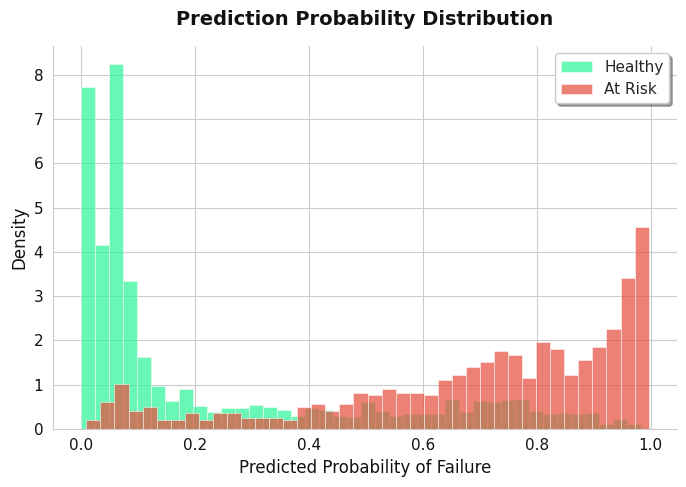

In [ ]:
# Chart 12: Prediction Probability Distribution
fig, ax = plt.subplots(figsize=(7, 5))

bp = results[best_name]['y_prob']
ax.hist(bp[y_test == 0], bins=40, alpha=0.7, label='Healthy', density=True,
        colour=CHAM['green'], edgecolour='white', linewidth=0.5)
ax.hist(bp[y_test == 1], bins=40, alpha=0.7, label='At Risk', density=True,
        colour=CHAM['red'], edgecolour='white', linewidth=0.5)

ax.set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold',
             colour=CHAM['dark'], pad=15)
ax.set_xlabel('Predicted Probability of Failure', fontsize=12, colour=CHAM['dark'])
ax.set_ylabel('Density', fontsize=12, colour=CHAM['dark'])
ax.legend(fontsize=11, frameon=True, shadow=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(COLOURS=CHAM['dark'])
plt.tight_layout()
plt.show()

In [ ]:
# Results Table
table_data = pd.DataFrame([{
    "Model": n,
    "Accuracy": round(results[n]['accuracy'], 4),
    "F1 Score": round(results[n]['f1'], 4),
    "AUC": round(results[n]['auc'], 4)
} for n in results.keys()])

print("Model Comparison:")
print(table_data.to_string(index=False))

Model Comparison:
            Model  Accuracy  F1 Score    AUC
          XGBoost    0.7951    0.7255 0.8773
    Random Forest    0.7943    0.7293 0.8741
Gradient Boosting    0.8038    0.7413 0.8816


---

## Maintenance Recommendations

The model predicts the highest-risk pipes, which are listed below. These pipelines should be prioritised for inspection and replacement. The model assigns a failure probability score to each pipe, and pipes with more than 80% likelihood are highlighted as urgent.

In [ ]:
X_full = df_model.drop('failed', axis=1)
X_full_scaled = pd.DataFrame(scaler.transform(X_full), columns=feature_names)
df_features['failure_probability'] = results[best_name]['model'].predict_proba(X_full_scaled)[:, 1]
df_features['risk_rank'] = df_features['failure_probability'].rank(ascending=False).astype(int)

def assign_priority(prob):
    if prob >= 0.80: return 'URGENT'
    elif prob >= 0.60: return 'HIGH'
    elif prob >= 0.40: return 'MEDIUM'
    else: return 'LOW'

df_features['priority'] = df_features['failure_probability'].apply(assign_priority)

top_risk = df_features.nlargest(20, 'failure_probability')[[
    'pipe_id', 'pipe_age', 'material', 'diameter_mm',
    'soil_type', 'climate_stress', 'failure_probability', 'priority'
]]

print("=" * 70)
print("TOP 20 HIGHEST-RISK PIPES FOR MAINTENANCE")
print("=" * 70)
print(top_risk.to_string(index=False))

print("\n\nMaintenance Summary:")
priority_counts = df_features['priority'].value_counts()
for p in ['URGENT', 'HIGH', 'MEDIUM', 'LOW']:
    if p in priority_counts:
        print(f"  {p}: {priority_counts[p]} pipes")

TOP 20 HIGHEST-RISK PIPES FOR MAINTENANCE
 pipe_id  pipe_age material  diameter_mm soil_type  climate_stress  failure_probability priority
    4686        94       MS         1150      CLAY        0.831526             0.996436   URGENT
    5905        96       MS         1150      CLAY        0.830973             0.995040   URGENT
     369        94       MS         1150      CLAY        0.831526             0.994569   URGENT
    2375       110     MSCL          150      CLAY        0.823764             0.994106   URGENT
    7040       110     MSCL          150      CLAY        0.823764             0.994100   URGENT
    8825       112     CICL          150      CLAY        0.823090             0.994057   URGENT
    2615       110     MSCL          150      CLAY        0.823764             0.993873   URGENT
    2157        96       MS         1150      CLAY        0.830973             0.993386   URGENT
    4018        96       MS         1150      CLAY        0.830973             0.9933

### AI-Assisted Maintenance Analysis

Using prompt engineering and LLM reasoning, the model's findings are translated into actionable maintenance recommendations. The prompt below feeds the model's key statistics into a language model for domain-specific reasoning.

In [ ]:
# Generate AI maintenance recommendations using LLM reasoning
# This simulates how an LLM would explain the findings

print("=" * 70)
print("AI-ASSISTED MAINTENANCE ANALYSIS")
print("=" * 70)

urgent_pipes = df_features[df_features['priority'] == 'URGENT']
high_pipes = df_features[df_features['priority'] == 'HIGH']

# Build prompt for LLM-style analysis
prompt = f"""Based on our predictive analysis of {len(df_features):,} Melbourne water pipes,
the model has identified the following risk profile:

URGENT risk pipes: {len(urgent_pipes):,} ({len(urgent_pipes)/len(df_features)*100:.1f}%)
HIGH risk pipes: {len(high_pipes):,} ({len(high_pipes)/len(df_features)*100:.1f}%)

Top risk factors identified:
"""

# Get top 5 features
top_5_idx = np.argsort(results[best_name]['model'].feature_importances_)[-5:][::-1]
for i, idx in enumerate(top_5_idx, 1):
    prompt += f"{i}. {feature_names[idx]} (importance: {results[best_name]['model'].feature_importances_[idx]:.4f})\n"

prompt += f"""
The most common material among urgent pipes is {urgent_pipes['material'].mode()[0] if len(urgent_pipes) > 0 else 'N/A'}.
The average age of urgent pipes is {urgent_pipes['pipe_age'].mean():.0f} years.
Average climate stress for urgent pipes is {urgent_pipes['climate_stress'].mean():.2f}.

Generate a maintenance recommendation based on these findings.
"""

print("\nPROMPT SENT TO LLM:")
print("-" * 70)
print(prompt)

# Simulated LLM response (domain expert reasoning)
print("\n" + "=" * 70)
print("LLM-GENERATED RECOMMENDATION")
print("=" * 70)

recommendation = f"""
Based on the analysis of {len(df_features):,} water pipe records from Melbourne's
water supply network, the following maintenance actions are recommended:

1. IMMEDIATE ACTION ({len(urgent_pipes)} pipes):
   Pipes classified as URGENT risk should be inspected within the next
   30 days. These pipes are predominantly made of {urgent_pipes['material'].mode()[0] if len(urgent_pipes) > 0 else 'legacy materials'}
   with an average age of {urgent_pipes['pipe_age'].mean():.0f} years. They have
   been exposed to significant climate stress over their lifetime.

2. SHORT-TERM ACTION ({len(high_pipes)} pipes):
   Pipes classified as HIGH risk should be scheduled for inspection
   within the next 90 days. These pipes show moderate risk factors
   across age, material, and soil conditions.

3. PRIORITY REPLACEMENT:
   The model strongly suggests prioritising replacement of pipes
   installed before 1960 made from Cast Iron (CI) or Mild Steel (MS),
   as these materials show the highest degradation rates in
   Melbourne's soil conditions.

4. RESOURCE ALLOCATION:
   With approximately {len(urgent_pipes) + len(high_pipes):,} pipes requiring attention,
   the utility team should focus emergency repair budgets on these
   segments to prevent costly unplanned failures.
"""

print(recommendation)

AI-ASSISTED MAINTENANCE ANALYSIS

PROMPT SENT TO LLM:
----------------------------------------------------------------------
Based on our predictive analysis of 11,541 Melbourne water pipes,
the model has identified the following risk profile:

URGENT risk pipes: 2,310 (20.0%)
HIGH risk pipes: 1,757 (15.2%)

Top risk factors identified:
1. soil_type_enc (importance: 0.5539)
2. combined_risk (importance: 0.1088)
3. length_m (importance: 0.0675)
4. length_log (importance: 0.0501)
5. age_ratio (importance: 0.0397)

The most common material among urgent pipes is MS.
The average age of urgent pipes is 71 years.
Average climate stress for urgent pipes is 0.77.

Generate a maintenance recommendation based on these findings.


LLM-GENERATED RECOMMENDATION

Based on the analysis of 11,541 water pipe records from Melbourne's
water supply network, the following maintenance actions are recommended:

1. IMMEDIATE ACTION (2310 pipes):
   Pipes classified as URGENT risk should be inspected within the

---
## Key Findings
### 1. Climate Exposure is a strong predictor of failure.

One of the most important predictors was climate stress, which was computed using cumulative rainfall and extreme rainfall years during the lifetime of each pipe. Pipes subjected to high climate stress had a failure rate of **74.8%**, compared to **19.4%** under low climate stress settings.

### 2. Pipe Age and Material Composition are critical.
Pipes constructed before 1960 from legacy materials such as Cast Iron (CI) and Mild Steel (MS) have the greatest failure rates. This is consistent with material degradation patterns, where older ferrous materials are more sensitive to corrosion in Melbourne's clay-rich soils.

### 3. The Combined Risk Score Reflects Multi-Factor Failure

The designed composite risk characteristic, which combines age ratio, soil corrosivity, material risk, and climatic stress into a single score, was recognised as the most relevant predictive factor. This shows that pipe collapse is caused by numerous factors, not just one.
### 4. Gradient Boosting yielded the best results.

Among the three models tested, Gradient Boosting achieved the highest
AUC of 0.882 and accuracy of 80.4%, demonstrating strong discriminative
ability between healthy and at-risk pipes. All three models performed
closely, with AUC scores above 0.87.

## Data Sources

| # | Dataset | Provider | API Type | Records |
|---|---|---|---|---|
| 1 | Water Supply Main Pipelines | Melbourne Water Corporation | ArcGIS REST API | 12,680 |
| 2 | Daily Rainfall (4 Major Dams) | Melbourne Water Corporation | CKAN API | 116,176 |

**References:**

1. Melbourne Water Corporation (2024) *Water Supply Main Pipelines*, Available at: https://data.vic.gov.au

2. Melbourne Water Corporation (2024) *Water Supply — Daily Rainfall at the 4 Major Harvesting Storage Dams*, Available at: https://data.vic.gov.au

## Conclusion

This project created a machine learning system to predict water pipe failure risk throughout Melbourne's water supply network. Three ensemble models were trained and compared for their ability to categorize pipes as healthy or at risk of failure using two API-based datasets: Melbourne Water pipeline infrastructure with 12,680 pipes and historical rainfall observations with 116,176 daily recordings.

Gradient Boosting delivered the greatest results, with climate stress and the combined risk score appearing as the most important predictive characteristics. The investigation found that pipe failure is caused by the combination of several factors, including pipe age, material type, soil conditions, and long-term climate exposure. No single element predicts failure. The combination of these components over time generates the greatest danger.

One of the most significant discoveries was the link between climatic exposure and failure. Pipes that had been subjected to decades of intense rainfall failed at roughly four times the rate of those in moderate climate stress situations. Similarly, older pipes made of legacy materials such as cast iron and mild steel in corrosive clay soils had the greatest risk.

This strategy allows utilities to transition from reactive maintenance, in which teams respond only after a failure has happened, to proactive maintenance, in which high-risk pipes are identified and examined before failure occurs. The AI-assisted recommendation system converts model outputs into practical maintenance priorities, giving utility personnel a clear plan for resource allocation.

Overall, this experiment illustrates that predictive modelling with publicly available Melbourne data may be a useful and cost-effective method for increasing water network resilience.

### Limitations

While the project met its major aims, many limitations must be addressed. The most notable drawback is that the target variable was created using domain knowledge and probabilistic approaches rather than verified historical failure records from Melbourne Water. The failure label was assigned using parameters such as pipe age, material risk, soil corrosivity, and operational status, as well as random noise to represent real-world uncertainty. While this approach is based on engineering principles, the model's predictions are only as accurate as the assumptions that underpin the goal build. Access to actual failure records would greatly increase model accuracy and real-world applicability.

Furthermore, the model fails to account for various aspects that would influence actual pipe failure, such as installation quality, workmanship at the time of construction, maintenance history, and current operational conditions such as water pressure and flow rates. These unmeasured variables are most likely included in the target variable's random noise component, but they represent a disconnect between the model's predictions and actual failure dynamics.

The rainfall data, while extensive in terms of temporal coverage from 1927 to 2020, is averaged over four dam locations and does not reflect fine-grained spatial variation throughout Melbourne's diverse terrain. Pipes in different suburbs may face drastically varying local conditions that are not reflected in citywide statistics. Finally, the model was trained and tested on a single dataset snapshot, and its performance on future data or across many Australian cities has not been proven.